# LightGBM Model

This notebook aims to build LightGBM Model.

## 0. Import Libraries


In [1]:
# Data Analysis Libraries
import pandas as pd 
import numpy as np 
from IPython.display import HTML, display 
from pprint import pprint

# Data Visualization Libraries 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Machine Learning Libraries
import lightgbm as lgb

# Data Preparation and Evaluation Libraries
import src.data_preprocess as dp
import src.evaluation as ev

print(f"Current pandas version: {pd.__version__}")
print(f"Current LightGBM version: {lgb.__version__}")

Current pandas version: 2.0.3
Current LightGBM version: 4.6.0


In [2]:
# - MLFlow Experiment Tracking -
import mlflow 

def set_or_create_experiment(name: str):
	exp = mlflow.get_experiment_by_name(name)
	if exp is None:
		mlflow.create_experiment(name)
		print(f"✅ Experiment '{name}' created.")

	mlflow.set_experiment(name)
	print(f"✅ Current experiment set to '{name}'.")


set_or_create_experiment("LightGBM Runs")

✅ Current experiment set to 'LightGBM Runs'.


## 1. Read Data


In [3]:
df1 = pd.read_csv("data/processed/creditcard_cleaned.csv")
df1.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
X_train, X_val, X_test, y_train, y_val, y_test = dp.train_val_test_split(df1, target_column='Class')

Initial Dataset shape: (283726, 30)
-----------------------------
X_train shape: (170235, 30) Pct: 60.0%
y_train shape: (170235,)
-----------------------------
X_val shape: (56745, 30) Pct: 20.0%
y_val shape: (56745,)
-----------------------------
X_test shape: (56746, 30) Pct: 20.0%
y_test shape: (56746,)


In [5]:
# - Check Class Distribution - 
print(y_train.value_counts() )
print(y_val.value_counts() ) 
print(y_test.value_counts())

Class
0    169951
1       284
Name: count, dtype: int64
Class
0    56651
1       94
Name: count, dtype: int64
Class
0    56651
1       95
Name: count, dtype: int64


## 2. Data Preparation for LightGBM


### Standardisation of Data


In [6]:
# - Scaling of Train, Validation, Test Data  - 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().set_output(transform="pandas")

# - Train StandardScaler() based on features in Train Data - 
X_train_scaled = scaler.fit_transform(X_train)

# - Apply Learning to Validation, Test Data - 
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

pd.set_option('display.max_columns', None)
display(X_train_scaled.describe(), X_val_scaled.describe(), X_test_scaled.describe())



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05
mean,8.932132e-17,2.637901e-17,-1.060169e-17,1.030952e-17,-1.552688e-17,-1.260516e-17,2.170425e-18,-1.352341e-17,3.172159e-18,7.513008e-18,1.094604e-17,1.243820e-17,1.035126e-17,2.045208e-17,-2.170425e-18,-1.477558e-17,1.844861e-17,-2.120338e-17,6.886924e-18,1.419124e-17,7.846920e-18,-1.669557e-18,1.101908e-17,-3.297376e-18,-3.145029e-17,-2.337380e-18,-1.602775e-17,-6.302579e-18,-3.589548e-18,7.713355e-17
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-1.998089e+00,-2.890460e+01,-4.385165e+01,-2.115123e+01,-3.948438e+00,-2.357710e+01,-1.976563e+01,-3.463469e+01,-6.269327e+01,-1.226384e+01,-2.267899e+01,-4.701531e+00,-1.866154e+01,-5.821694e+00,-2.010732e+01,-4.923274e+00,-1.550930e+01,-2.842044e+01,-1.135137e+01,-8.851848e+00,-3.085285e+01,-4.822267e+01,-1.512209e+01,-7.196027e+01,-4.679219e+00,-1.971052e+01,-5.411684e+00,-5.726023e+01,-3.516209e+01,-3.577232e-01
25%,-8.572931e-01,-4.714192e-01,-3.585194e-01,-5.906398e-01,-5.976386e-01,-5.102166e-01,-5.789135e-01,-4.636778e-01,-1.791937e-01,-5.877955e-01,-4.969855e-01,-7.482822e-01,-4.076322e-01,-6.513810e-01,-4.454874e-01,-6.356828e-01,-5.344683e-01,-5.722884e-01,-5.984716e-01,-5.610092e-01,-2.762023e-01,-3.183692e-01,-7.488514e-01,-2.639275e-01,-5.855511e-01,-6.105171e-01,-6.791548e-01,-1.827592e-01,-1.605461e-01,-3.346759e-01
50%,-2.098539e-01,7.004965e-03,4.175699e-02,1.155985e-01,-1.451939e-02,-4.247452e-02,-2.062127e-01,3.217413e-02,1.883438e-02,-4.601050e-02,-8.493811e-02,-3.121043e-02,1.397536e-01,-1.316594e-02,5.232488e-02,5.456459e-02,7.667120e-02,-7.740606e-02,-4.188127e-03,3.627222e-03,-8.114761e-02,-4.244436e-02,1.069129e-02,-2.122442e-02,6.792648e-02,3.009123e-02,-1.082681e-01,-2.096535e-04,3.246766e-02,-2.682930e-01
75%,9.345406e-01,6.717175e-01,4.854011e-01,6.821729e-01,5.245662e-01,4.475205e-01,3.036905e-01,4.749735e-01,2.785386e-01,5.453091e-01,4.228990e-01,7.260222e-01,6.206344e-01,6.653301e-01,5.171133e-01,7.080094e-01,5.969175e-01,4.708802e-01,5.980427e-01,5.625704e-01,1.742499e-01,2.560106e-01,7.291303e-01,2.354969e-01,7.269346e-01,6.716726e-01,4.982311e-01,2.268882e-01,2.330045e-01,-4.295246e-02
max,1.638532e+00,1.255593e+00,1.295009e+01,6.234214e+00,1.190102e+01,2.555992e+01,1.616643e+01,2.861917e+01,1.677149e+01,1.423682e+01,2.206956e+01,1.177859e+01,7.895283e+00,4.590601e+00,1.101767e+01,6.327680e+00,8.072688e+00,1.095197e+01,6.016780e+00,6.838629e+00,5.143609e+01,3.130516e+01,1.452616e+01,3.617607e+01,6.630274e+00,1.439292e+01,7.307421e+00,3.083059e+01,1.016220e+02,7.940123e+01


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000,56745.000000
mean,-0.003000,0.001203,-0.000537,-0.005975,-0.001856,-0.000442,0.000348,-0.005063,-0.003663,-0.010001,-0.003796,0.000360,0.003756,-0.007011,-0.002505,-0.000316,0.007986,0.005105,-0.008716,0.005686,0.006968,-0.006576,-0.001860,-0.012330,0.008606,-0.005780,0.001098,0.001382,0.004783,0.003677
std,0.997880,0.991019,0.979376,1.007839,0.996808,0.994907,0.999910,1.005577,1.005030,0.995009,0.989682,0.993153,0.992702,0.995773,0.994761,1.001232,0.996151,0.990685,1.000872,0.993951,0.963416,0.999559,1.007433,1.019098,0.999097,0.994246,1.000586,0.963585,0.908881,0.988877
min,-1.998089,-24.010069,-27.502962,-22.392592,-4.006660,-23.036926,-13.278190,-36.345524,-35.522521,-12.159852,-22.850996,-4.589278,-17.328744,-3.982490,-19.353240,-4.592505,-16.157191,-29.773814,-10.806784,-6.052868,-30.557033,-31.564362,-12.292114,-52.723391,-4.659782,-16.649977,-4.657645,-18.433687,-25.116036,-0.357723
25%,-0.854999,-0.472044,-0.361405,-0.599494,-0.598627,-0.509390,-0.580375,-0.463027,-0.179936,-0.589084,-0.496969,-0.740360,-0.403462,-0.658136,-0.447504,-0.640570,-0.528478,-0.568053,-0.601182,-0.550473,-0.271773,-0.320708,-0.751595,-0.262537,-0.578072,-0.608542,-0.677965,-0.183221,-0.157442,-0.334432
50%,-0.218841,0.007301,0.041415,0.115670,-0.014719,-0.041845,-0.208762,0.029590,0.016844,-0.056893,-0.088979,-0.028731,0.139763,-0.017904,0.051672,0.045480,0.084915,-0.070840,-0.013591,0.013404,-0.077193,-0.044014,0.006233,-0.020211,0.076539,0.025247,-0.106358,0.000304,0.033329,-0.267481
75%,0.936919,0.671717,0.489373,0.673994,0.520910,0.450315,0.296637,0.473817,0.276424,0.535671,0.423514,0.723655,0.621895,0.658526,0.510575,0.712254,0.605580,0.473134,0.588054,0.572138,0.178117,0.254539,0.736119,0.233556,0.732800,0.665686,0.498843,0.231474,0.239955,-0.039930
max,1.638617,1.254034,13.306231,2.806426,9.259294,18.107366,16.013136,25.777705,17.130638,8.430430,14.161281,11.435878,4.875749,4.390603,7.038829,6.372691,7.367902,9.153227,5.064473,5.953995,30.857514,37.656770,11.501594,29.489126,6.569699,10.476809,6.555277,20.519304,44.956384,47.481102


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000
mean,-0.010131,0.002581,0.004129,-0.003216,-0.003782,-0.011545,0.003190,0.000074,-0.003654,0.003375,0.002485,0.000688,-0.002889,0.004661,0.009220,0.000739,0.001054,0.005982,-0.006707,-0.004517,-0.001270,-0.011605,-0.001074,0.000359,0.003574,-0.006030,-0.001356,0.001380,-0.004812,0.002655
std,0.998690,0.999646,0.986068,1.006660,0.989381,1.060935,1.031806,1.111341,1.042183,1.005303,1.012198,0.998586,1.009743,1.006017,0.987764,1.003618,0.999243,0.994077,1.000435,0.996888,1.057559,1.011280,1.003147,0.988684,0.998228,0.994616,1.007068,1.054934,1.011743,1.087979
min,-1.998046,-19.246442,-23.098725,-32.127700,-3.818481,-83.554194,-16.568485,-27.736527,-43.403192,-9.898022,-19.468882,-4.028060,-18.792324,-3.836459,-18.888814,-4.383468,-15.212687,-25.688244,-10.864177,-5.667899,-71.106072,-31.691372,-9.828792,-58.885307,-4.563715,-12.851976,-3.564847,-25.111305,-46.328475,-0.357723
25%,-0.860324,-0.471897,-0.357181,-0.599417,-0.601240,-0.511783,-0.580044,-0.463493,-0.180315,-0.587745,-0.495367,-0.747151,-0.411804,-0.648923,-0.437852,-0.638790,-0.534142,-0.569446,-0.600782,-0.563917,-0.274317,-0.320657,-0.757046,-0.258112,-0.580323,-0.608087,-0.680836,-0.184093,-0.162256,-0.335447
50%,-0.220272,0.012604,0.042123,0.121016,-0.015413,-0.046402,-0.204596,0.031624,0.016924,-0.044569,-0.083981,-0.034511,0.144627,-0.013557,0.059634,0.053731,0.070486,-0.077149,-0.012693,-0.002323,-0.081297,-0.048313,0.005157,-0.018659,0.069111,0.030175,-0.113025,-0.000475,0.029977,-0.270139
75%,0.928142,0.673532,0.483461,0.679061,0.517604,0.437107,0.298966,0.468669,0.278980,0.551086,0.420251,0.722395,0.623883,0.672271,0.518885,0.713724,0.598412,0.482164,0.592840,0.556282,0.173001,0.251239,0.727034,0.232009,0.725397,0.666177,0.501125,0.225552,0.227840,-0.047325
max,1.638490,1.243079,10.073677,2.606231,10.793076,24.171464,55.389165,100.614222,13.523153,9.487812,12.682094,11.003956,4.601783,7.161166,8.116512,9.711926,19.800532,10.896981,4.838256,6.862999,31.490066,27.773390,11.440680,30.514456,7.567990,9.202330,7.195020,80.206288,47.636122,103.887534


In [7]:
# - Check Scaling Validity Manually - 
dp.check_scaling_validity(X_train_scaled)
dp.check_scaling_validity(X_val_scaled)
dp.check_scaling_validity(X_test_scaled)

✅ Feature means after scaling:
 Time      8.932132e-17
V1        2.637901e-17
V2       -1.060169e-17
V3        1.030952e-17
V4       -1.552688e-17
V5       -1.260516e-17
V6        2.170425e-18
V7       -1.352341e-17
V8        3.172159e-18
V9        7.513008e-18
V10       1.094604e-17
V11       1.243820e-17
V12       1.035126e-17
V13       2.045208e-17
V14      -2.170425e-18
V15      -1.477558e-17
V16       1.844861e-17
V17      -2.120338e-17
V18       6.886924e-18
V19       1.419124e-17
V20       7.846920e-18
V21      -1.669557e-18
V22       1.101908e-17
V23      -3.297376e-18
V24      -3.145029e-17
V25      -2.337380e-18
V26      -1.602775e-17
V27      -6.302579e-18
V28      -3.589548e-18
Amount    7.713355e-17
dtype: float64
-----------------------------------

✅ Feature std devs after scaling:
 Time      1.000003
V1        1.000003
V2        1.000003
V3        1.000003
V4        1.000003
V5        1.000003
V6        1.000003
V7        1.000003
V8        1.000003
V9        1.000003
V

### SMOTE Application on Train Data


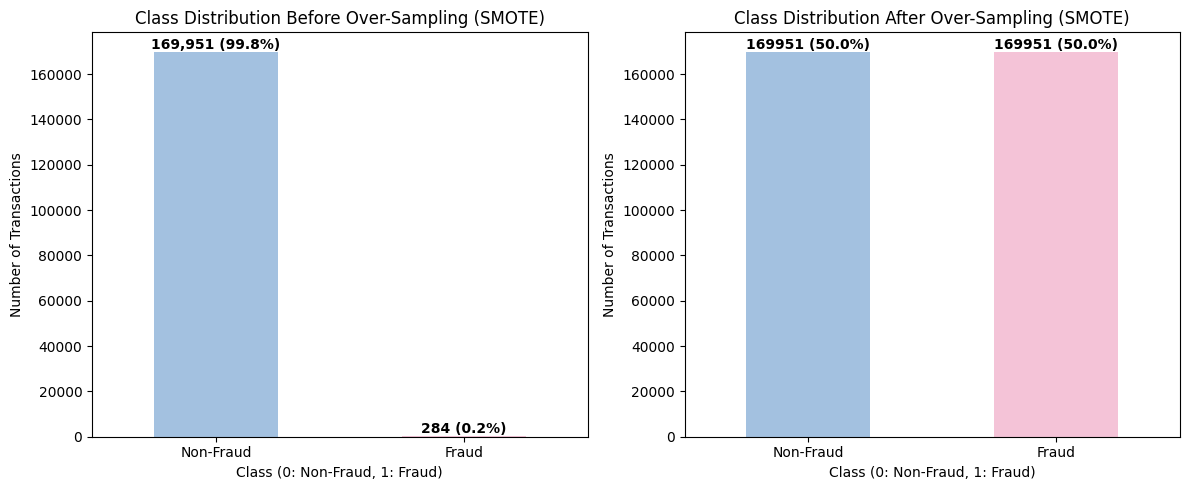

In [8]:
X_train_resampled, y_train_resampled = dp.ApplySmote.fit_resample(X_train_scaled, y_train)

## 3. LightGBM Model Training


[LightGBM] [Info] Number of positive: 169951, number of negative: 169951
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.000000
[LightGBM] [Debug] init for col-wise cost 0.000003 seconds, init for row-wise cost 0.006260 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008276 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 339902, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 28 and depth = 5
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Debug] Trained a tree with leaves = 29 and depth = 5
[LightGBM] [Warning] No further splits w

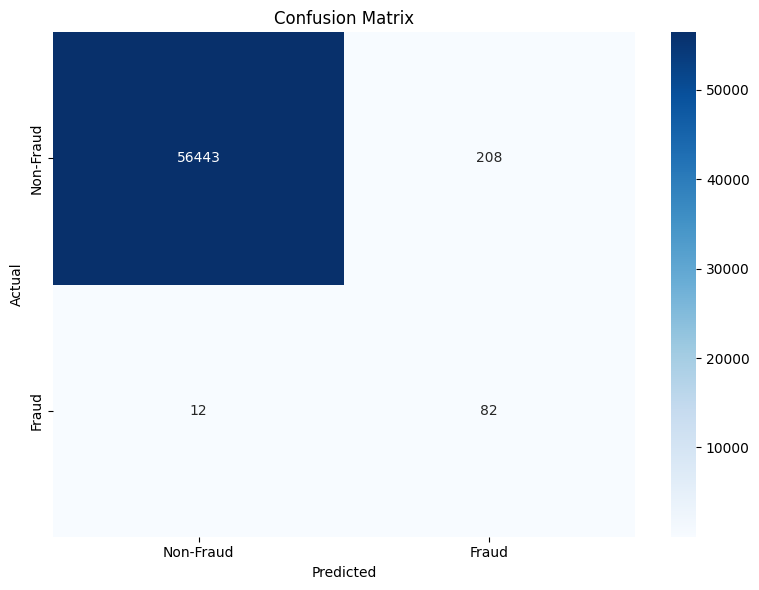

In [9]:
import lightgbm as lgb

# - Model Instatiation with Parameters -
lightgbm_params={
      'objective': 'binary', # objective function: log loss 
      'max_depth': 5, 
      'n_jobs': -1,  # use all CPU Cores
      'random_state': 42, 
      'device_type': 'cpu', # can adjust to GPU
      'early_stopping_round': 50, 
      'verbose': 10 
   }

lightgbm_model = lgb.LGBMClassifier(**lightgbm_params)
lightgbm_model.fit(X_train_resampled, y_train_resampled, 
        eval_set=[(X_train_resampled, y_train_resampled), (X_val_scaled, y_val)], 
        eval_names = ['Training', 'Validation'],
        eval_metric='binary_logloss')


# - Predict & Analyse Results - 
y_pred_labels_val = lightgbm_model.predict(X_val_scaled)
y_proba_all = lightgbm_model.predict_proba(X_val_scaled)
positive_class_proba = y_proba_all[:, 1]
results = ev.ResultsAnalyser.analyze_predictions(y_val, y_pred_labels_val, positive_class_proba, model_name='LightGBM (Untuned)')

## 3. Baseline LightGBM Model Diagnostics


<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='binary_logloss'>

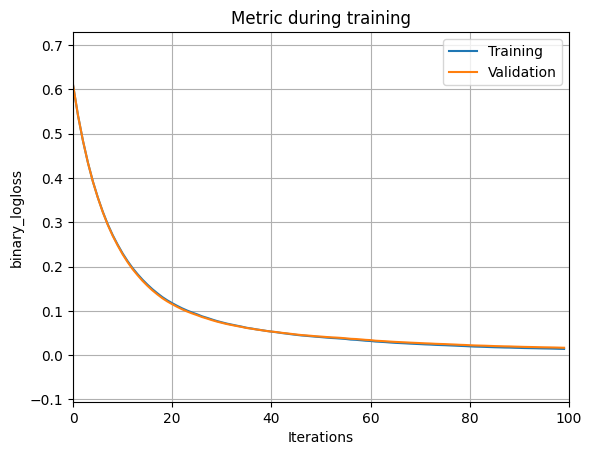

In [14]:
lgb.plot_metric(lightgbm_model)

## 4. Hyperparameter Tuning

We will be using Optuna for hyperparameter tuning to fix the issues identified with our model. With Bayesian Optimization, Optuna is better than Random Search & Grid Search due to its speed and effectiveness. Let's first define an objective function, before letting Optuna search through the defined search space to find the best hyperparameters. Based on my research from sources like Medium and Kaggle, I have collected a list of hyperparameters most likely to solve our model's issue. This objective function should attempt to optimise F1 Score & Recall concurrently (Multi-Objective Optuna Optimization).


In [11]:
# Import required libraries for hyperparameter tuning
import optuna
from sklearn.metrics import f1_score, recall_score

ModuleNotFoundError: No module named 'optuna'

In [ ]:

# def objective(trial):
#   """
#   Objective function for optimizing LightGBM AUC
#   """
  
#   params = {
#         # Learning parameters
#         'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3), # random increments in search space 
#         'num_iterations': trial.suggest_int('num_iterations', 100, 1000),
        
#         # Tree structure parameters
#         'max_depth': trial.suggest_int('max_depth', 3, 12),
#         'num_leaves': trial.suggest_int('num_leaves', 10, 300),
#         'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 100),
#         'max_bin': trial.suggest_int('max_bin', 63, 512),
        
#         # Regularization parameters
#         'lambda_l1': trial.suggest_float('lambda_l1', 0.0, 10.0),
#         'lambda_l2': trial.suggest_float('lambda_l2', 0.0, 10.0),
#         'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 5.0),
#         'path_smooth': trial.suggest_float('path_smooth', 0.0, 100.0),
        
#         # Sampling parameters
#         'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
#         'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
#         'bagging_freq': trial.suggest_int('bagging_freq', 0, 7),
        
#         # Boosting type
#         'boosting_type': trial.suggest_categorical('boosting_type', ['gbdt', 'dart', 'goss']),
        
#         # Fixed parameters
#         'objective': 'binary',
#         'metric': 'binary_logloss',
#         'random_state': 42,
#         'n_jobs': -1,
#         'device_type': 'cpu',
#         'verbose': -1
#      }
  
#   # Define & Train LightGBM Model
#   model = lgb.LGBMClassifier(**params)
#   model.fit(X_train_resampled, y_train_resampled, 
#             eval_set=[(X_val_scaled, y_val)], 
#             eval_metric='binary_logloss',
#             early_stopping_rounds=100,
#             verbose=0)

#   # Evaluate on Validation Set (Mu)
#   y_pred = model.predict(X_val_scaled) # class labels
#   y_proba_val = model.predict_proba(X_val_scaled)[:,1] # actual probabilities predicted 
#   f1score = f1_score(y_val, y_pred, zero_division=0) # f1 score of positive class
#   recall = recall_score(y_val, y_pred, zero_division=0) # recall of positive class
#   return f1score, recall

# study = optuna.create_study(direction = 'maximize')
# study.optimize(objective,n_trials = 100)

## 6. Model Evaluation II (Validation Set)


## 7. Model Evaluation (Test Set)
